In [1]:
# Google Colab instructions
# Runtime > Change Runtime Type > Runtime Version > 2025.07
# This cell should say you're now on Python Version 3.11.

import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [2]:
!pip install pycaret openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyod to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.7 MB/s eta 0:00:00


In [1]:
# Before running: Runtime > Restart Session

from pycaret.regression import *

In [2]:
import pandas as pd

df = pd.read_excel("sipri_data1.xlsx")

In [3]:
#df = df.dropna(subset=['ME_spending_%_GDP_lead_1_year'])

#Military Expenditure as Percentage of GDP Regression

In [4]:
regression_pipeline = setup(
    data=df,
    target='ME_spending_%_GDP',
    categorical_features=['year'],
    ignore_features=[
        'GPR_index',
        'companies_in_sipri_top_100',
        'is_in_NATO?',
        'export_coverage_ratio',
        'export_TIV_millions',
        'is_US_top_supplier_country?',
        'top_supplier_country',
        'import_TIV_millions',
        'country',
        'ME_spending_%_GDP_lead_1_year',
        'ME_per_capita_in_USD',
        'ME_%_gov_budget',
        'ME_spending_%_GDP_growth_rate',
        'import_growth_rate',
        'import_export_ratio',
        'export_growth_rate',
    ],
    numeric_imputation='median',
    #categorical_imputation='constant',
    normalize=True,
    session_id=42,
    train_size=0.8,
    fold = 5
)

,Description,Value
0,Session id,42
1,Target,ME_spending_%_GDP
2,Target type,Regression
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(180, 6)"
5,Transformed train set shape,"(144, 6)"
6,Transformed test set shape,"(36, 6)"
7,Ignore features,16
8,Numeric features,1
9,Categorical features,1


In [5]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,0.0048,0.0001,0.0084,0.8164,0.0074,0.2512,0.0900
huber,Huber Regressor,0.0116,0.0017,0.0320,0.0284,0.0278,0.5901,0.0600
lasso,Lasso Regression,0.0147,0.0018,0.0342,-0.3794,0.0300,1.0405,0.0560
dummy,Dummy Regressor,0.0147,0.0018,0.0342,-0.3794,0.0300,1.0405,0.0580
llar,Lasso Least Angle Regression,0.0147,0.0018,0.0342,-0.3794,0.0300,1.0405,0.0600
en,Elastic Net,0.0147,0.0018,0.0342,-0.3794,0.0300,1.0405,0.0560
omp,Orthogonal Matching Pursuit,0.0157,0.0017,0.0344,-0.7290,0.0293,0.8826,0.0520
br,Bayesian Ridge,0.0153,0.0018,0.0344,-0.7490,0.0297,0.9028,0.0560
et,Extra Trees Regressor,0.0154,0.0021,0.0364,-0.8341,0.0319,0.6916,0.2600
knn,K Neighbors Regressor,0.0152,0.0019,0.0370,-1.0720,0.0325,0.7914,0.0680


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [6]:
xgboost_model = create_model('xgboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0029,0.0000,0.0040,0.7350,0.0040,0.2545
1,0.0039,0.0000,0.0050,0.7872,0.0049,0.2475
2,0.0058,0.0002,0.0130,0.9650,0.0106,0.1597
3,0.0052,0.0001,0.0084,0.6333,0.0081,0.3630
4,0.0061,0.0001,0.0118,0.9616,0.0094,0.2313
Mean,0.0048,0.0001,0.0084,0.8164,0.0074,0.2512
Std,0.0012,0.0001,0.0036,0.1298,0.0026,0.0653


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
tuned_xgboost = tune_model(xgboost_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0031,0.0000,0.0035,0.8035,0.0034,0.2674
1,0.0038,0.0000,0.0045,0.8242,0.0044,0.2701
2,0.0131,0.0025,0.0501,0.4837,0.0400,0.2073
3,0.0045,0.0001,0.0078,0.6831,0.0075,0.2732
4,0.0037,0.0000,0.0051,0.9928,0.0050,0.2112
Mean,0.0056,0.0005,0.0142,0.7575,0.0121,0.2458
Std,0.0037,0.0010,0.0180,0.1688,0.0140,0.0300


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [8]:
from pycaret.regression import get_config

X_train = get_config('X_train')
X_train.head()

,year,aerial_distance_moscow_km
117,2023,2146.979980
65,2023,1608.829956
67,2025,1608.829956
31,2025,1777.410034
12,2022,1927.380005


In [9]:
X_train_process = get_config('X_train_transformed')
X_train_process.head()

,year_2023.0,year_2025.0,year_2022.0,year_2024.0,aerial_distance_moscow_km
117,1.834022,-0.609449,-0.566658,-0.588043,0.319107
65,1.834022,-0.609449,-0.566658,-0.588043,-0.452703
67,-0.545250,1.640825,-0.566658,-0.588043,-0.452703
31,-0.545250,1.640825,-0.566658,-0.588043,-0.210927
12,-0.545250,-0.609449,1.764734,-0.588043,0.004159


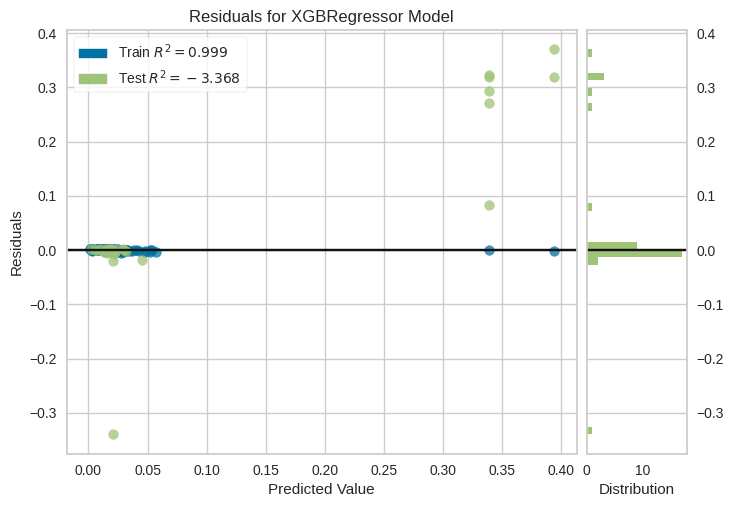

In [10]:
plot_model(tuned_xgboost, plot='residuals')

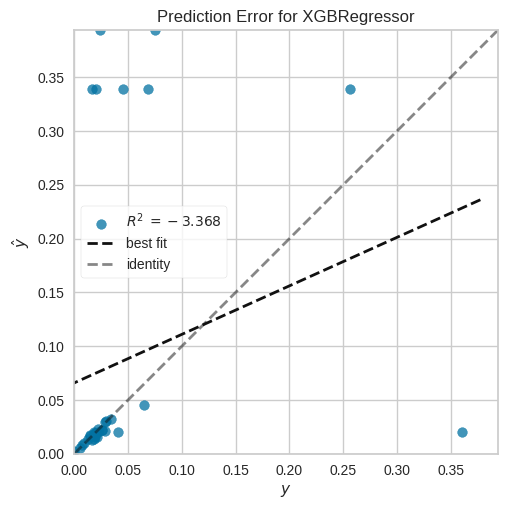

In [11]:
plot_model(tuned_xgboost, plot='error')

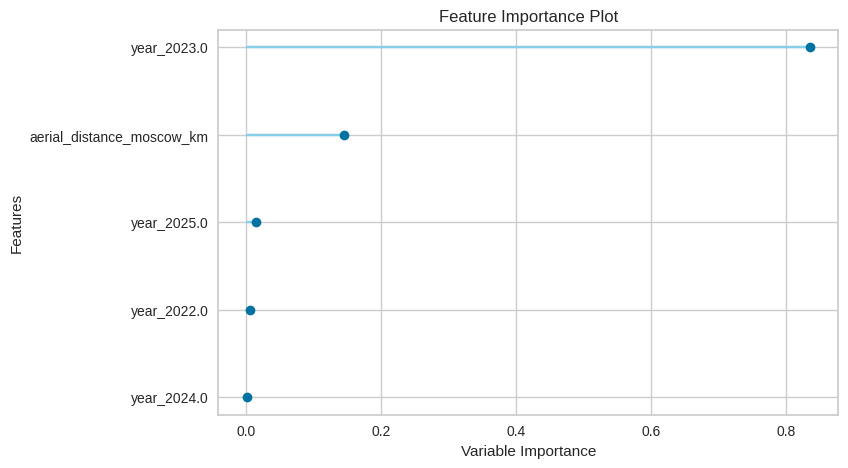

In [12]:
plot_model(tuned_xgboost, plot='feature')

In [13]:
evaluate_model(tuned_xgboost)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…